In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
combined = pd.read_csv("../finaldata/combined_events.csv")
combined.columns

combined = combined.drop(columns=['DATE','Attendance_Ratio','AWARDED'])


## One-hot encoding

In [4]:
# Identify categorical and numeric columns
categorical_cols = ['Event_Type', 'A.S. Advertisement Pass', 'Location_Type', 'Day_of_Week']
numeric_cols = ['log_AWARDED', 'log_Attendance_Ratio']

# One-hot encode categorical variables
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
encoded = encoder.fit_transform(combined[categorical_cols]).toarray()

# Convert encoded features to DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=combined.index)

# Add numeric columns back into encoded DataFrame
combined_encoded = pd.concat([encoded_df, combined[numeric_cols].reset_index(drop=True)], axis=1)

print("Shape:", combined_encoded.shape)
print(combined_encoded.columns[:10])

# Optional: Verify the encoded DataFrame
combined_encoded.head()


Shape: (442, 30)
Index(['Event_Type_GBM', 'Event_Type_Other', 'Event_Type_Recruitment',
       'Event_Type_Religion', 'Event_Type_Social', 'Event_Type_Speaker',
       'Event_Type_Workshop', 'A.S. Advertisement Pass_Yes',
       'Location_Type_Mandeville Auditorium', 'Location_Type_Muir'],
      dtype='object')


,Event_Type_GBM,Event_Type_Other,Event_Type_Recruitment,Event_Type_Religion,Event_Type_Social,Event_Type_Speaker,Event_Type_Workshop,A.S. Advertisement Pass_Yes,Location_Type_Mandeville Auditorium,Location_Type_Muir,...,Location_Type_Warren,Location_Type_Wong-Avery,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,log_AWARDED,log_Attendance_Ratio
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.377135,0.378299
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.469169,0.433210
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.382611,0.585562
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.012002,0.934838
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.825109,0.757389


In [7]:
y = combined_encoded['log_Attendance_Ratio']
X = combined_encoded.drop(columns=['log_Attendance_Ratio'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.logspace(-4, 4, 100)
l1_space = np.linspace(0.0, 1.0, 11)

elastic = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_space,
    cv=10,
    max_iter=10000,
    selection="random",
    n_jobs=-1
)

elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)



/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mse_test = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse_test)


r2_test = r2_score(y_test, y_pred)
print("Test R²:", r2_test)


Test MSE: 0.20692728745981948
Test R²: 0.15544504785594693


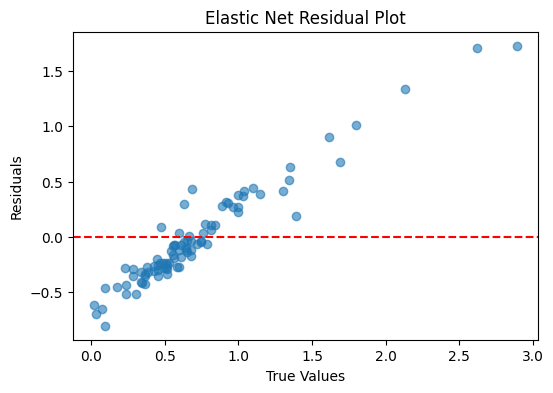

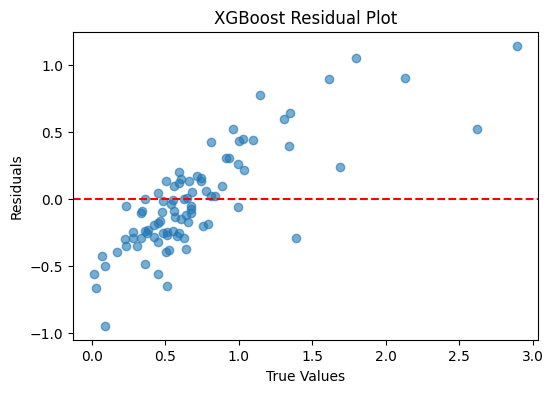

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_test - y_pred, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("Elastic Net Residual Plot")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_test - y_pred_xgb, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("XGBoost Residual Plot")
plt.show()


## XGBoost

In [13]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print("XGB R²:", r2_score(y_test, y_pred_xgb))
print("XGB MSE:", mean_squared_error(y_test, y_pred_xgb))


XGB R²: 0.40700909202124846
XGB MSE: 0.14529072355193404


/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


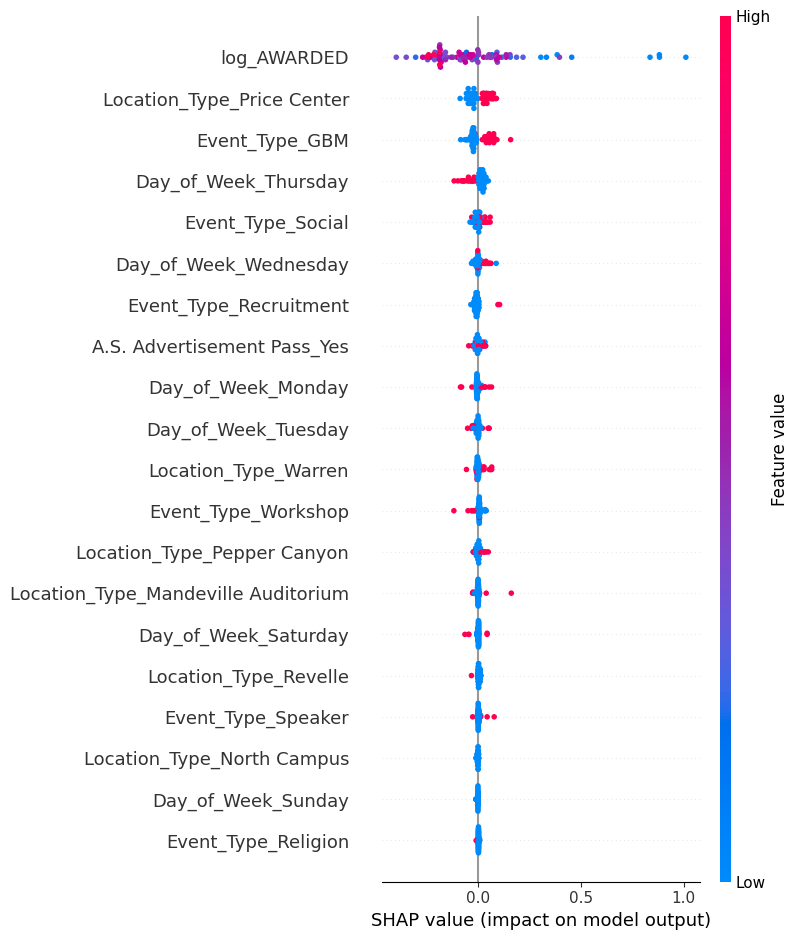

In [17]:
importances = xgb.feature_importances_

import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)



## CV Scores for Both Models

In [18]:
from sklearn.model_selection import cross_val_score

# Elastic Net CV error (10-fold)
enet_cv_mse = -cross_val_score(elastic, X_train_scaled, y_train, 
                               cv=10, scoring='neg_mean_squared_error')
print("Elastic Net CV MSE:", enet_cv_mse.mean())

# XGBoost CV error (10-fold)
xgb_cv_mse = -cross_val_score(xgb, X_train_scaled, y_train, 
                              cv=10, scoring='neg_mean_squared_error')
print("XGB CV MSE:", xgb_cv_mse.mean())


/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram

Elastic Net CV MSE: 0.13479110339165412
XGB CV MSE: 0.13815885356245416
